In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_lnn_memory_impact(
    n_neuron=256,
    input_dim=19,                  
    
    # --- 1. Baseline: FP32 (Software / GPU Standard) ---
    fp32_bits=32,                   
    
    # --- 2. Competitor: INT8 (Standard Edge NPU) ---
    int8_bits=8,                   
    # CAM/LUTの設定
    prop_cam_in_bits=8,            
    prop_lut_out_bits=8,          
    prop_processor_sram_bits=8,          
    prop_processor_rram_bits=8,            
    prop_weight_bits=8,
    block=None,
    bit_range=[1,2,3,4,5,6,7,8],                          
):
    """
    FP32, INT8, 提案手法の3つのメモリ容量を比較するシミュレーション
    各量子化パラメータはリストでも単一値でも可
    """
    if block is not None:
        if block=="CAM":
            prop_cam_in_bits = bit_range
        elif block=="LUT":
            prop_lut_out_bits = bit_range
        elif block=="SRAM":
            prop_processor_sram_bits = bit_range
        elif block=="RRAM":
            prop_processor_rram_bits = bit_range
        elif block=="Weight":
            prop_weight_bits = bit_range    
        else:
            raise ValueError("Invalid block name for sweeping bits.")
    
    results = []
    
    # 各パラメータがリストかどうか判定し、リスト化
    def ensure_list(x):
        return x if isinstance(x, (list, tuple, np.ndarray)) else [x]

    cam_bits_list = ensure_list(prop_cam_in_bits)
    lut_bits_list = ensure_list(prop_lut_out_bits)
    proc_sram_bits_list = ensure_list(prop_processor_sram_bits)
    proc_rram_bits_list = ensure_list(prop_processor_rram_bits)
    weight_bits_list = ensure_list(prop_weight_bits)

    for cam_bits in cam_bits_list:
        for lut_bits in lut_bits_list:
            for proc_sram_bits in proc_sram_bits_list:
                for proc_rram_bits in proc_rram_bits_list:
                    for weight_bits in weight_bits_list:
                        # 共通パラメータ: 重みの総数
                        total_params_weight = (n_neuron + input_dim) * n_neuron
                        
                        # 1. Baseline: FP32 (Full Precision)
                        size_fp32_mvm = total_params_weight * fp32_bits
                        total_fp32_kbits = size_fp32_mvm / 1000
                        
                        # 2. Competitor: INT8 (Standard Quantization)
                        size_int8_mvm = total_params_weight * int8_bits * 2
                        size_int8_cam = (2**int8_bits) * int8_bits # CAM overhead
                        size_int8_lut = n_neuron * (2**int8_bits) * int8_bits # LUT overhead
                        size_int8_processor = 4 * n_neuron * int8_bits # その他プロセッサオーバーヘッド
                        total_int8_kbits = (size_int8_mvm + size_int8_cam + size_int8_lut + size_int8_processor) / 1000
                        
                        # 3. Proposed (Mixed Precision & Architecture)
                        size_prop_mvm = total_params_weight * weight_bits * 2
                        entries = 2 ** cam_bits
                        size_prop_cam = entries * cam_bits # Key
                        size_prop_lut = n_neuron * entries * lut_bits # Value
                        size_prop_processor = n_neuron * (3 * proc_rram_bits + proc_sram_bits) # その他プロセッサオーバーヘッド
                        total_prop_kbits = (size_prop_mvm + size_prop_cam + size_prop_lut + size_prop_processor) / 1000
                        
                        swept_bit = None
                        if block == "CAM":
                            swept_bit = cam_bits
                        elif block == "LUT":
                            swept_bit = lut_bits
                        elif block == "SRAM":
                            swept_bit = proc_sram_bits
                        elif block == "RRAM":
                            swept_bit = proc_rram_bits
                        elif block == "Weight":
                            swept_bit = weight_bits

                        # 削減率の計算 (vs FP32)
                        reduction_vs_fp32 = (total_prop_kbits / total_fp32_kbits) * 100
                        reduction_vs_int8 = (total_prop_kbits / total_int8_kbits) * 100
                        
                        results.append({
                            "bit": swept_bit,
                            "Neuron Count": n_neuron,
                            "CAM Size": size_prop_cam,
                            "LUT Size": size_prop_lut,
                            "Processor Size": size_prop_processor,
                            "MVM Size": size_prop_mvm,
                            "FP32 Size (kbits)": total_fp32_kbits,
                            "INT8 Size (kbits)": total_int8_kbits,
                            "Ours Size (kbits)": total_prop_kbits,
                            "Red. vs FP32 (%)": reduction_vs_fp32,
                            "Red. vs INT8 (%)": reduction_vs_int8,
                        })
    return pd.DataFrame(results)

In [137]:
def plot_quantization_results(block, bit_range):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import glob
    import re
    import pandas as pd

    # =====================
    # Config
    # =====================
    units = [64, 128, 256]
    base_path = f"/work/robomimic/csv/result/quantize/{block}"
    TOP_K = 10

    sns.set_style("white")

    custom_colors = {
        "u64": "#351fb4",
        "u128": "#06a600",
        "u256": "#d62728",
    }
    markers = {
        "u64": "s",
        "u128": "o",
        "u256": "^",
    }

    TICK_SIZE = 25

    # =====================
    # Load success-rate CSVs
    # =====================
    def extract_bit(path):
        m = re.search(r"([0-9.]+)bit.csv", path)
        return float(m.group(1)) if m else None

    results = []

    for unit in units:
        files = glob.glob(f"{base_path}/unit{unit}/*.csv")

        for f in files:
            bit = extract_bit(f)
            if bit is None:
                continue

            # ★ 1bitファイルを除外（ここでスキップする）
            if float(bit) == 1.0:
                continue

            df = pd.read_csv(f)
            topk = df.nlargest(TOP_K, "success_rate")

            results.append({
                "unit": unit,
                "bit": bit,
                "mean_success": topk["success_rate"].mean(),
                "std_success": topk["success_rate"].std()
            })

    results_df = pd.DataFrame(results)

    # =====================
    # Memory analysis
    # =====================
    df_mem = analyze_lnn_memory_impact(block=block, bit_range=bit_range)
    df_mem = df_mem[["bit", "Ours Size (kbits)","Red. vs INT8 (%)"]].copy()
    df_mem["bit"] = df_mem["bit"].astype(float)
    df_mem = df_mem.sort_values("bit").reset_index(drop=True)

    merged = results_df.merge(df_mem, on="bit", how="left").sort_values(["unit", "bit"])
    merged["diff_success_rate"] = merged.groupby("unit")["mean_success"].diff()
    merged["diff_memory_kbits"] = merged.groupby("unit")["Red. vs INT8 (%)"].diff()
    merged["gain_per_kbit"] = merged["diff_success_rate"] / merged["diff_memory_kbits"] * 100

    # ==== きれいに出力（表形式）====
    summary = merged.copy()
    summary["mean_success_%"] = summary["mean_success"] * 100.0
    summary["diff_success_pp"] = summary["diff_success_rate"] * 100.0  # 変化量をppで見せる
    summary["diff_red_vs_int8_pp"] = summary["diff_memory_kbits"]       # (Red. vs INT8) の差分 = pp

    summary = summary[[
        "unit",
        "bit",
        "mean_success_%",
        "diff_success_pp",
        "Red. vs INT8 (%)",
        "diff_red_vs_int8_pp",
        "gain_per_kbit",
    ]].sort_values(["unit", "bit"]).reset_index(drop=True)

    summary = summary.round({
        "mean_success_%": 2,
        "diff_success_pp": 2,
        "Red. vs INT8 (%)": 2,
        "diff_red_vs_int8_pp": 2,
        "gain_per_kbit": 4,
    })

    print(summary.to_string(index=False))

    # =====================
    # Figure
    # =====================
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    # =====================
    # Left axis: Success Rate
    # =====================
    for unit in units:
        df_u = (
            results_df[results_df["unit"] == unit]
            .sort_values("bit")
        )

        ax1.plot(
            df_u["bit"],
            df_u["mean_success"] * 100,
            color=custom_colors[f"u{unit}"],
            linewidth=3,
            zorder=5,
        )

        ax1.scatter(
            df_u["bit"],
            df_u["mean_success"] * 100,
            marker=markers[f"u{unit}"],
            s=180,
            facecolors="white",
            edgecolors=custom_colors[f"u{unit}"],
            linewidths=3,
            zorder=6,
        )

        ax1.errorbar(
            df_u["bit"],
            df_u["mean_success"] * 100,
            yerr=df_u["std_success"] * 100,
            fmt="none",
            ecolor=custom_colors[f"u{unit}"],
            elinewidth=2.5,
            capsize=6,
            zorder=4,
        )

    # =====================
    # Right axis: Memory
    # =====================
    ax2.bar(
        df_mem["bit"],
        df_mem["Red. vs INT8 (%)"],
        width=0.8,
        color="#9A9898",
        zorder=2,
    )

    # =====================
    # Axis style
    # =====================
    ax1.set_xlim(min(bit_range) - 0.5, max(bit_range) + 0.5)
    ax1.set_ylim(0, 105)

    ax1.set_xticks(bit_range)
    ax1.set_yticks(np.arange(0, 101, 20))

    ax1.tick_params(axis="both", labelsize=TICK_SIZE, width=2.5)
    ax2.tick_params(axis="y", labelsize=TICK_SIZE, width=2.5)

    for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
        t.set_fontweight("bold")

    ax2.yaxis.grid(True, linestyle="--", linewidth=1.0)
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
    for spine in ax2.spines.values():
        spine.set_linewidth(2.5)

    plt.tight_layout()
    plt.show()


 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0            7.70              NaN             68.80                  NaN            NaN
   64  3.0           86.40            78.70             69.30                 0.49       159.2532
   64  4.0           95.10             8.70             70.29                 0.99         8.7981
   64  5.0           97.80             2.70             72.27                 1.98         1.3646
   64  6.0           98.30             0.50             76.23                 3.96         0.1263
   64  7.0           97.40            -0.90             84.15                 7.92        -0.1136
   64  8.0           96.37            -1.02            100.00                15.85        -0.0647
  128  2.0            7.20              NaN             68.80                  NaN            NaN
  128  3.0           78.30            71.10             69.30                 0.49       143.8742
  128  4.0          

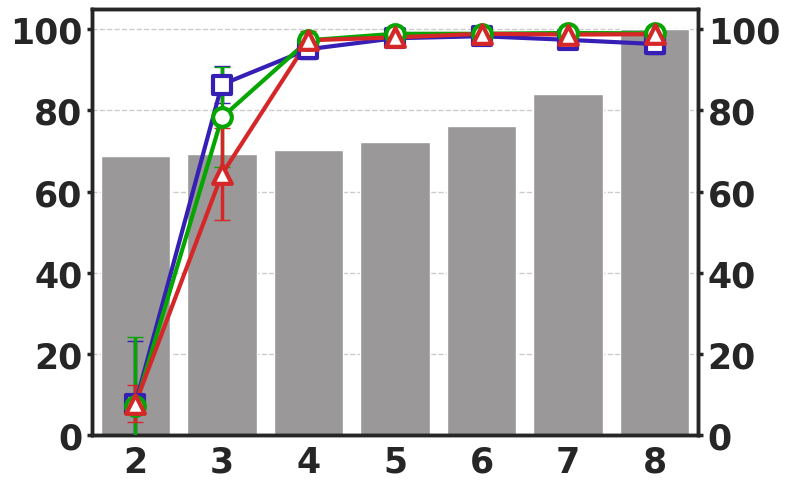

 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0            92.0              NaN             76.33                  NaN            NaN
   64  3.0            96.9              4.9             80.27                 3.95         1.2418
   64  4.0            98.6              1.7             84.22                 3.95         0.4308
   64  5.0            98.2             -0.4             88.16                 3.95        -0.1014
   64  6.0            98.3              0.1             92.11                 3.95         0.0253
   64  7.0            98.4              0.1             96.05                 3.95         0.0253
   64  8.0            98.6              0.2            100.00                 3.95         0.0507
  128  2.0            92.3              NaN             76.33                  NaN            NaN
  128  3.0            98.0              5.7             80.27                 3.95         1.4446
  128  4.0          

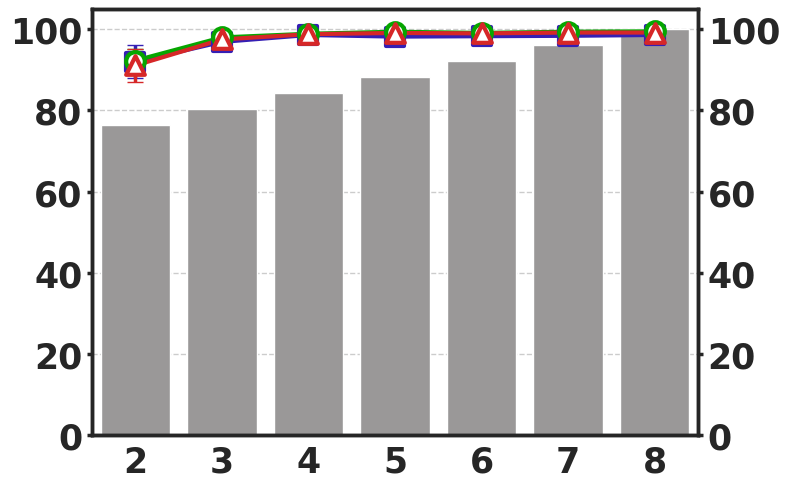

 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0             1.3              NaN             49.14                  NaN            NaN
   64  3.0            21.7             20.4             57.61                 8.48         2.4065
   64  4.0            87.9             66.2             66.09                 8.48         7.8092
   64  5.0            96.2              8.3             74.57                 8.48         0.9791
   64  6.0            98.2              2.0             83.05                 8.48         0.2359
   64  7.0            98.4              0.2             91.52                 8.48         0.0236
   64  8.0            98.2             -0.2            100.00                 8.48        -0.0236
  128  2.0             2.7              NaN             49.14                  NaN            NaN
  128  3.0            72.7             70.0             57.61                 8.48         8.2575
  128  4.0          

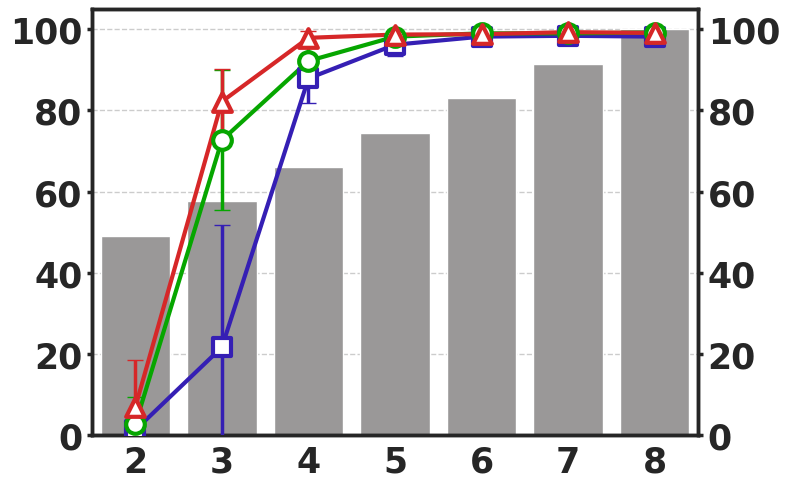

 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0            46.9              NaN             99.91                  NaN            NaN
   64  3.0            87.4             40.5             99.92                 0.02       2627.640
   64  4.0            96.2              8.8             99.94                 0.02        570.944
   64  5.0            96.9              0.7             99.95                 0.02         45.416
   64  6.0            97.9              1.0             99.97                 0.02         64.880
   64  7.0            98.5              0.6             99.98                 0.02         38.928
   64  8.0            98.6              0.1            100.00                 0.02          6.488
  128  2.0            40.3              NaN             99.91                  NaN            NaN
  128  3.0            89.1             48.8             99.92                 0.02       3166.144
  128  4.0          

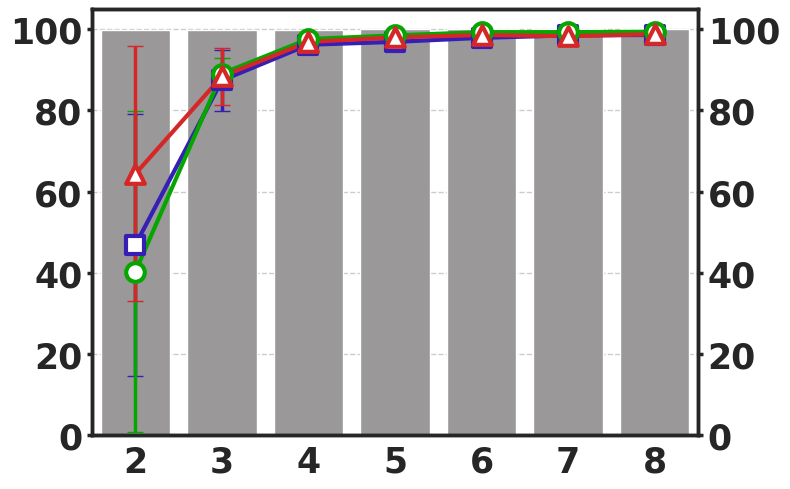

 unit  bit  mean_success_%  diff_success_pp  Red. vs INT8 (%)  diff_red_vs_int8_pp  gain_per_kbit
   64  2.0            90.4              NaN             99.72                  NaN            NaN
   64  3.0            98.5              8.1             99.77                 0.05       175.1760
   64  4.0            99.0              0.5             99.82                 0.05        10.8133
   64  5.0            98.6             -0.4             99.86                 0.05        -8.6507
   64  6.0            98.5             -0.1             99.91                 0.05        -2.1627
   64  7.0            98.5             -0.0             99.95                 0.05        -0.0000
   64  8.0            98.5              0.0            100.00                 0.05         0.0000
  128  2.0            95.0              NaN             99.72                  NaN            NaN
  128  3.0            98.5              3.5             99.77                 0.05        75.6933
  128  4.0          

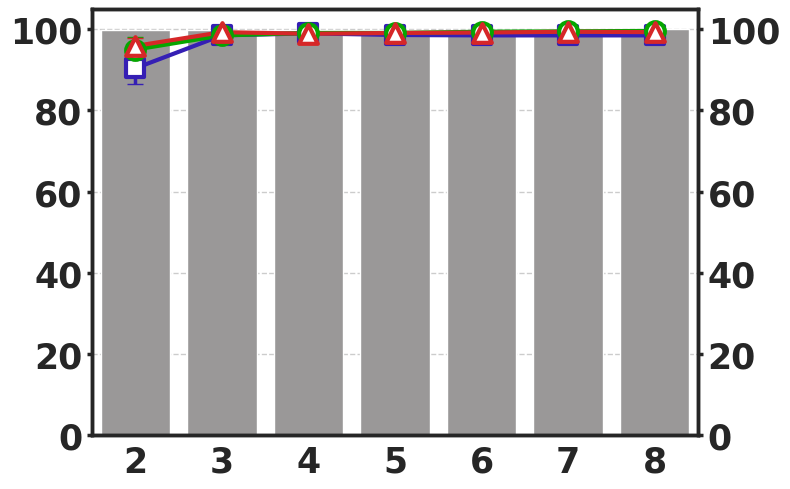

In [138]:
# CAM 
blocks=["CAM","LUT","Weight","SRAM","RRAM"]
for block in blocks:
    plot_quantization_results(block=block, bit_range=[2,3,4,5,6,7,8])

In [152]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import glob
import re
import pandas as pd

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/quantize/proposal/5-4-5"
TOP_K = 10  # 上位k行で平均

results = []

for unit in units:
    pattern = f"{base_path}/unit{unit}.csv"
    files = sorted(glob.glob(pattern))

    for f in files:

        df = pd.read_csv(f)

        # 行そのものから success_rate 上位kを選択
        topk = df.nlargest(TOP_K, "success_rate")
        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()

        results.append({
            "unit": unit,
            "mean_success": mean_success,
            "std_success": std_success
        })

results_df = pd.DataFrame(results)
print(results_df)

   unit  mean_success  std_success
0    64         0.941     0.036040
1   128         0.973     0.021108
2   256         0.942     0.034577


In [151]:
print(analyze_lnn_memory_impact(prop_cam_in_bits=5, prop_lut_out_bits=4, prop_weight_bits=5))

    bit  Neuron Count  CAM Size  LUT Size  Processor Size  MVM Size  \
0  None           256       160     32768            8192    704000   

   FP32 Size (kbits)  INT8 Size (kbits)  Ours Size (kbits)  Red. vs FP32 (%)  \
0             2252.8           1660.928             745.12         33.075284   

   Red. vs INT8 (%)  
0         44.861668  
